Extension of the LLM Teacher-Student experiments to the genre classification. Here, we will automatically annotate the X-GENRE train dataset with the genre labels with the GPT-4o model.

Then, we fine-tune XLM-RoBERTa model on the automatically annotated dataset with excatly the same settings that we used for fine-tuning the model on the manually-annotated X-GENRE dataset.

Then we apply it to X-GENRE test set, EN-GINCO and multilingual X-GENRE test set and compare the difference, compared to the original X-GENRE classifier.

Use the emma_main kernel

In [1]:
# Define the gpu on the gpu machine
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0

import pandas as pd
import json
import numpy as np
import tarfile
import os
from collections import Counter
import matplotlib.pyplot as plt
from time import sleep
from sklearn.model_selection import train_test_split
from openai import OpenAI
from tqdm import tqdm
client = OpenAI(api_key=open('key.txt').read())

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0


## Predict on X-GENRE train

In [ ]:
# Open the X-GENRE train dataset
from datasets import load_dataset
import pandas as pd

train = load_dataset("TajaKuzman/X-GENRE-multilingual-text-genre-dataset", "train")

# To open as Pandas DataFrame:
train_df = pd.DataFrame(train["train"])

In [6]:
train_df.head(3)

,text,labels,dataset,language
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English
2,Abstract Objective: Reporting bias due to soci...,Information/Explanation,CORE,English


In [7]:
train_df.describe()

,text,labels,dataset,language
count,1772,1772,1772,1772
unique,1772,9,3,2
top,"Seeking All Things Brilliant ""I want people to...",News,FTD,English
freq,1,344,630,1237


In [11]:
# Truncate the texts to first 512 words - to be used for GPT-4o prediction
trunc_texts = []

for text in train_df["text"].to_list():
	current_trunc_text = " ".join(text.split(' ')[:512])
	trunc_texts.append(current_trunc_text)

train_df["trunc_text"] = trunc_texts

train_df.head(3)

,text,labels,dataset,language,trunc_text
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English,"Seeking All Things Brilliant ""I want people to..."
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English,Meet Orchid du Bois I first met Hayley Mowday ...
2,Abstract Objective: Reporting bias due to soci...,Information/Explanation,CORE,English,Abstract Objective: Reporting bias due to soci...


In [ ]:
texts = train_df["trunc_text"].to_list()
print(texts[:2])
len(texts)

In [16]:
labels_list=['Other', 'Information/Explanation', 'News', 'Instruction', 'Opinion/Argumentation', 'Forum', 'Prose/Lyrical', 'Legal', 'Promotion']

In [19]:
label_dict = {x[1]:x[0] for x in enumerate(labels_list)}

reverse_dict = {x[0]:x[1] for x in enumerate(list(label_dict.keys()))}

label_dict

{'Other': 0,
 'Information/Explanation': 1,
 'News': 2,
 'Instruction': 3,
 'Opinion/Argumentation': 4,
 'Forum': 5,
 'Prose/Lyrical': 6,
 'Legal': 7,
 'Promotion': 8}

In [21]:
f=open(f'temp_prediction_x-genre-train-GPT4o.jsonl','wt')


In [22]:
def predict_genre(model, prompt, df):
	responses = []
	texts = train_df["trunc_text"].to_list()

	for text in tqdm(texts):
		completion = client.chat.completions.create(model=model,
		response_format={ "type": "json_object"},
		messages=[
		{
			"role": "user",
			"content": prompt + f"\nText: '{text}'"}
		],
		temperature = 0)
		response=completion.choices[0].message.content

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Convert the string into a dictionary
		response = json.loads(response)

		# Get out a label
		try:
			predicted = reverse_dict[response["genre"]]
			responses.append(predicted)
		# add a possibility of something going wrong
		except:
			predicted = "error"
			responses.append(predicted)
		
		instance={'text': text,'label': predicted}
		f.write(json.dumps(instance)+'\n')
		f.flush()

	train_df["genre_GPT"] = responses

	return df

We use the prompt with the extended description.

In [23]:
label_dict_with_description_ext = {
 'Other - a text that which does not fall under any of other genre categories.': 0,
 'Information/Explanation - an objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Common features: objective/factual, explanation/definition of a concept (x is …), enumeration.': 1,
 'News - an objective or subjective text which reports on an event recent at the time of writing or coming in the near future. Common features: adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense.': 2,
 'Instruction - an objective text which instructs the readers on how to do something. Common features: multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …).': 3,
 'Opinion/Argumentation - a subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. This genre includes a subjective narration of a personal experience as well. Common features: adjectives/adverbs that convey opinion, words that convey (un)certainty (certainly, surely), 1st person, exclamation marks.': 4,
 'Forum - a text in which people discuss a certain topic in form of comments. Common features: multiple authors, informal language, subjective (the writers express their opinions), written in 1st person.': 5,
 'Prose/Lyrical - a literary text that consists of paragraphs or verses. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art.': 6,
 'Legal -an objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Common features: objective/factual, legal terms, 3rd person.': 7,
 'Promotion - a subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. Common features: contains adjectives/adverbs that promote something (high-quality, perfect, amazing), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks.': 8
 }

In [24]:
structured_prompt_label_description = f"""
			### Task
			Your task is to classify the provided text into a genre label. In genre classification, you need to classify texts according to genres based on their conventional function and form, and the author's purpose. You will be provided with a text, delimited by single quotation marks. Always provide a label, even if you are not sure.

			### Output format
			Return a valid JSON dictionary with the following key: 'genre' and a value should be an integer which represents one of the labels according to the following dictionary: {label_dict_with_description_ext}.
			"""

In [25]:
df = predict_genre("gpt-4o-2024-05-13", structured_prompt_label_description, train_df)

df.head()

100%|██████████| 1772/1772 [16:11<00:00,  1.82it/s]


,text,labels,dataset,language,trunc_text,genre_GPT
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English,"Seeking All Things Brilliant ""I want people to...",Opinion/Argumentation
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English,Meet Orchid du Bois I first met Hayley Mowday ...,Opinion/Argumentation
2,Abstract Objective: Reporting bias due to soci...,Information/Explanation,CORE,English,Abstract Objective: Reporting bias due to soci...,Information/Explanation
3,In 2009 the song was the focus of a successful...,Information/Explanation,CORE,English,In 2009 the song was the focus of a successful...,News
4,QuotW This was the week when neither rumours o...,News,CORE,English,QuotW This was the week when neither rumours o...,News


Prediction on 1772 instances cost 10.36€ and took 16 minutes.

In [26]:
df.head(5)

,text,labels,dataset,language,trunc_text,genre_GPT
0,"Seeking All Things Brilliant ""I want people to...",Other,CORE,English,"Seeking All Things Brilliant ""I want people to...",Opinion/Argumentation
1,Meet Orchid du Bois I first met Hayley Mowday ...,Other,CORE,English,Meet Orchid du Bois I first met Hayley Mowday ...,Opinion/Argumentation
2,Abstract Objective: Reporting bias due to soci...,Information/Explanation,CORE,English,Abstract Objective: Reporting bias due to soci...,Information/Explanation
3,In 2009 the song was the focus of a successful...,Information/Explanation,CORE,English,In 2009 the song was the focus of a successful...,News
4,QuotW This was the week when neither rumours o...,News,CORE,English,QuotW This was the week when neither rumours o...,News


In [27]:
# Save the dataset
df.to_json("X-GENRE-train-with-GPT-predictions.jsonl", orient="records", lines=True)

Evaluate GPT-4o prediction based on the manually annotated labels

In [33]:
def testing(test_df, y_pred_column, test_name):
    """
    This function takes the test dataset and applies the trained model on it to infer predictions.
    It also prints and saves a confusion matrix, calculates the F1 scores and saves the results in a list of results.

    Args:
    - test_df (pandas DataFrame)
    - y_pred_column: column with predictionst
    - test_name
    """
    import matplotlib.pyplot as plt
    from sklearn import metrics
    from sklearn.metrics import classification_report, confusion_matrix, f1_score,precision_score, recall_score

    # Get the true labels
    y_true = test_df.labels.to_list()
    LABELS = list(test_df.labels.unique())
    y_pred = test_df[y_pred_column].to_list()

    # Calculate the scores
    macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
    micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
    print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")
    
    print(classification_report(y_true, y_pred))

    # Plot the confusion matrix:
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    plt.figure(figsize=(9, 9))
    plt.imshow(cm, cmap="Oranges")
    for (i, j), z in np.ndenumerate(cm):
        plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
    classNames = LABELS
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=90)
    plt.yticks(tick_marks, classNames)
    plt.title(f"{test_name}")

    plt.tight_layout()
    fig1 = plt.gcf()
    plt.show()
    plt.draw()
    #fig1.savefig(f"Confusion-matrix-{test_name}.png",dpi=100)

Macro f1: 0.698, Micro f1: 0.757
                         precision    recall  f1-score   support

                  Forum       0.72      0.88      0.79       140
Information/Explanation       0.67      0.81      0.73       306
            Instruction       0.84      0.77      0.80       210
                  Legal       0.81      0.88      0.84        64
                   News       0.78      0.82      0.80       344
  Opinion/Argumentation       0.71      0.61      0.65       242
                  Other       0.00      0.00      0.00        70
              Promotion       0.81      0.77      0.79       287
          Prose/Lyrical       0.83      0.92      0.87       109

               accuracy                           0.76      1772
              macro avg       0.68      0.72      0.70      1772
           weighted avg       0.73      0.76      0.74      1772



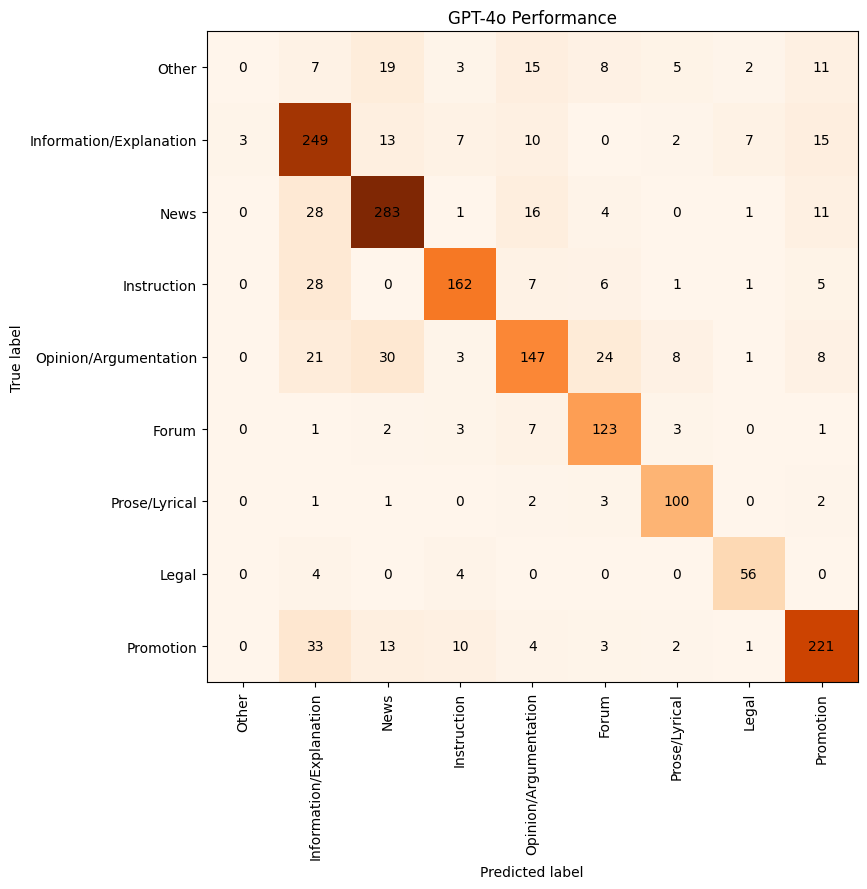

<Figure size 640x480 with 0 Axes>

In [34]:
testing(df, "genre_GPT", "GPT-4o Performance")

In [35]:
# Let's also calculate performance if we discard the Other instances

df_filtered = df[df["labels"] != "Other"]
df_filtered.shape

(1702, 6)

Macro f1: 0.802, Micro f1: 0.789


/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

                         precision    recall  f1-score   support

                  Forum       0.75      0.88      0.81       140
Information/Explanation       0.68      0.81      0.74       306
            Instruction       0.85      0.77      0.81       210
                  Legal       0.84      0.88      0.85        64
                   News       0.83      0.82      0.83       344
  Opinion/Argumentation       0.76      0.61      0.68       242
                  Other       0.00      0.00      0.00         0
              Promotion       0.84      0.77      0.80       287
          Prose/Lyrical       0.86      0.92      0.89       109

               accuracy                           0.79      1702
              macro avg       0.71      0.72      0.71      1702
           weighted avg       0.79      0.79      0.79      1702



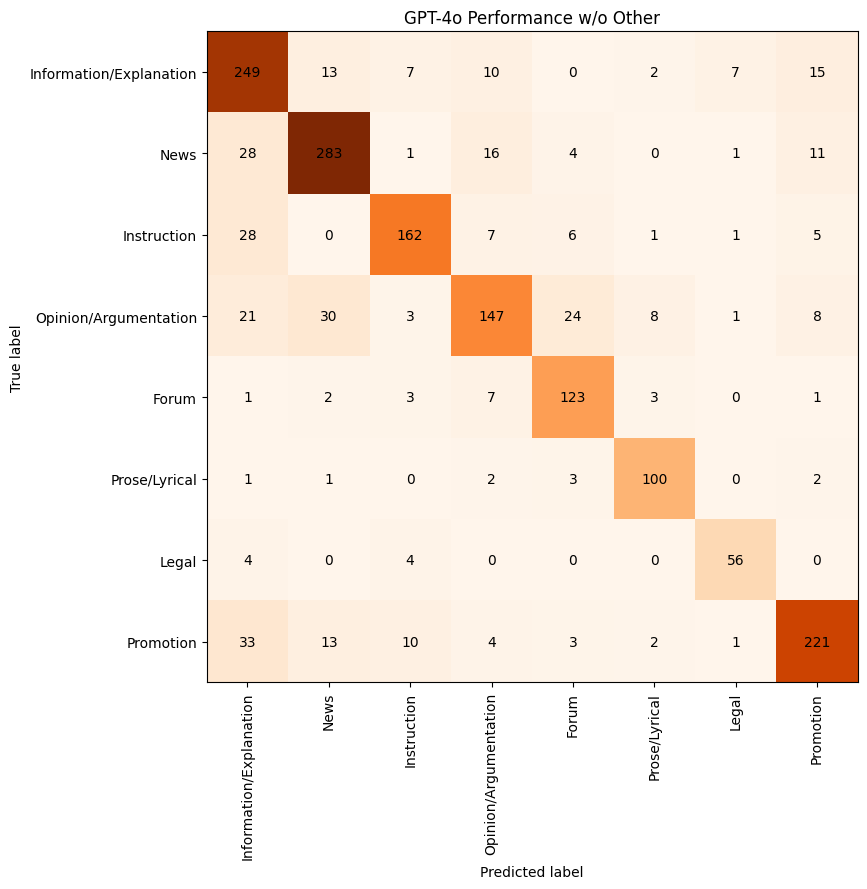

<Figure size 640x480 with 0 Axes>

In [36]:
testing(df_filtered, "genre_GPT", "GPT-4o Performance w/o Other")

# Fine-tune a XLM-RoBERTa model on the dataset

Use the script in `extension-to-genre/train-and-eval-genre-model.py` (with emma_main env):
```CUDA_VISIBLE_DEVICES=0 nohup python train-and-eval-genre-model.py "v1" > train-model-v1.log```

# Evaluate models

In [2]:
# Define the gpu on the gpu machine
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0

import pandas as pd
import json
import numpy as np
import os
from collections import Counter
from tqdm import tqdm
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
from datasets import load_dataset
import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0


/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def apply_model(test_df, model_path):
	# Define the model hyperparameters
	model_args= {
	            "num_train_epochs": 15,
	            "learning_rate": 1e-5,
	            "max_seq_length": 512,
	            "silent": True
	            }

	model = ClassificationModel(
	    "xlmroberta",
	    model_path,
	    use_cuda=True,
	    args=model_args
	)

	# Calculate the model's predictions on test
	def make_prediction(input_string):
		return model.predict([input_string])[0][0]

	y_pred = test_df.text.apply(make_prediction)
	test_df[f"pred_{model_path}"] = y_pred

	return test_df

In [26]:
def apply_x_genre(test_df):
	from transformers import pipeline

	pipe = pipeline("text-classification", model="classla/xlm-roberta-base-multilingual-text-genre-classifier", device="cuda:0")

	texts = test_df["text"].to_list()

	outputs = pipe(texts, truncation=True)

	y_preds = []

	for output in outputs:
		y_preds.append(output["label"])
	
	test_df["pred_X-GENRE"] = y_preds

	return test_df

In [3]:
def testing(test_df, y_pred_column, test_name, figure=False):
    """
    This function takes the test dataset and applies the trained model on it to infer predictions.
    It also prints and saves a confusion matrix, calculates the F1 scores and saves the results in a list of results.

    Args:
    - test_df (pandas DataFrame)
    - y_pred_column: column with predictions
    - test_name
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import classification_report, confusion_matrix, f1_score

    # Get the true labels
    y_true = test_df.labels.to_list()
    LABELS = list(test_df.labels.unique())
    y_pred = test_df[y_pred_column].to_list()

    # Calculate the scores
    macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
    micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
    print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")
    
    print(classification_report(y_true, y_pred))
    
    if figure == True:
        # Plot the confusion matrix:
        cm = confusion_matrix(y_true, y_pred, labels=LABELS)
        plt.figure(figsize=(9, 9))
        plt.imshow(cm, cmap="Oranges")
        for (i, j), z in np.ndenumerate(cm):
            plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
        classNames = LABELS
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        tick_marks = np.arange(len(classNames))
        plt.xticks(tick_marks, classNames, rotation=90)
        plt.yticks(tick_marks, classNames)
        plt.title(f"{test_name}")

        plt.tight_layout()
        fig1 = plt.gcf()
        plt.show()
        plt.draw()
        #fig1.savefig(f"Confusion-matrix-{test_name}.png",dpi=100)
    
    return {"micro-F1": micro, "macro-F1": macro}

In [4]:
# Open the file with the results
with open("genre-experiments-results.json", "r") as results_file:
	results_dict = json.load(results_file)

results_dict

{'x-genre-test': {'X-GENRE-GPT-v3': {'micro-F1': 0.7466216216216216,
   'macro-F1': 0.6909763790831134},
  'X-GENRE-GPT-v1': {'micro-F1': 0.731418918918919,
   'macro-F1': 0.6811367813960743},
  'X-GENRE-GPT-v2': {'micro-F1': 0.7432432432432432,
   'macro-F1': 0.6916591344409126},
  'X-GENRE': {'micro-F1': 0.7972972972972973, 'macro-F1': 0.7935772031981144}},
 'enginco': {'X-GENRE-GPT-v1': {'micro-F1': 0.6985294117647058,
   'macro-F1': 0.5962511231154254},
  'X-GENRE-GPT-v2': {'micro-F1': 0.7095588235294118,
   'macro-F1': 0.6097373829328476},
  'X-GENRE-GPT-v3': {'micro-F1': 0.6875, 'macro-F1': 0.5805292768371353},
  'X-GENRE': {'micro-F1': 0.6838235294117647, 'macro-F1': 0.6862472150541707}},
 'multilingual-X-GENRE-test': {'X-GENRE-GPT-v1': {'micro-F1': 0.7632911392405063,
   'macro-F1': 0.7655957945514474},
  'X-GENRE-GPT-v2': {'micro-F1': 0.7569620253164557,
   'macro-F1': 0.7628347246090763},
  'X-GENRE-GPT-v3': {'micro-F1': 0.7518987341772152,
   'macro-F1': 0.7550345588279587},

## X-GENRE test

In [6]:
# Open the X-GENRE test from the HuggingFace
#test = load_dataset("TajaKuzman/X-GENRE-text-genre-dataset", "test")

#test_df = pd.DataFrame(test["train"])

test_df = pd.read_json("datasets/X-GENRE-test.jsonl", orient="records", lines=True)

print(test_df.shape)

test_df.head(3)

(592, 8)


,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Instruction,Instruction,Forum
2,Almost a quarter of Republicans think Obama 'm...,News,CORE,English,News,News,News,News


In [17]:
# Truncate the texts to first 512 words - to be used for GPT-4o prediction
trunc_texts = []

for text in test_df["text"].to_list():
	current_trunc_text = " ".join(text.split(' ')[:512])
	trunc_texts.append(current_trunc_text)

test_df["trunc_text"] = trunc_texts
test_df.head(2)

,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE,trunc_text
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum,"grantarctic1 Never caught one Neels, but off t..."
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Instruction,Instruction,Forum,Go back to Windows 7 or XP operating system If...


In [7]:
x_genre_dict = results_dict["x-genre-test"]
x_genre_dict

{'X-GENRE-GPT-v3': {'micro-F1': 0.7466216216216216,
  'macro-F1': 0.6909763790831134},
 'X-GENRE-GPT-v1': {'micro-F1': 0.731418918918919,
  'macro-F1': 0.6811367813960743},
 'X-GENRE-GPT-v2': {'micro-F1': 0.7432432432432432,
  'macro-F1': 0.6916591344409126},
 'X-GENRE': {'micro-F1': 0.7972972972972973, 'macro-F1': 0.7935772031981144}}

In [40]:
model_path = "X-GENRE-GPT-v2"

x_genre_dict[model_path] = testing(test_df, f"pred_{model_path}", f"{model_path} on X-GENRE-test")

Macro f1: 0.692, Micro f1: 0.743
                         precision    recall  f1-score   support

                  Forum       0.82      0.85      0.83        47
Information/Explanation       0.62      0.83      0.71       102
            Instruction       0.84      0.75      0.79        71
                  Legal       0.74      0.91      0.82        22
                   News       0.70      0.81      0.75       114
  Opinion/Argumentation       0.71      0.57      0.63        81
                  Other       0.00      0.00      0.00        23
              Promotion       0.88      0.74      0.80        95
          Prose/Lyrical       0.87      0.92      0.89        37

               accuracy                           0.74       592
              macro avg       0.69      0.71      0.69       592
           weighted avg       0.73      0.74      0.73       592



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [12]:
# Apply the original model
test_df = apply_x_genre(test_df)

test_df.head(3)

,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Instruction,Instruction,Forum
2,Almost a quarter of Republicans think Obama 'm...,News,CORE,English,News,News,News,News


In [13]:
# Evaluate the model
model_path = "X-GENRE"

x_genre_dict[model_path] = testing(test_df, f"pred_{model_path}", f"{model_path} on X-GENRE-test")

Macro f1: 0.794, Micro f1: 0.797
                         precision    recall  f1-score   support

                  Forum       0.90      0.81      0.85        47
Information/Explanation       0.80      0.80      0.80       102
            Instruction       0.80      0.83      0.81        71
                  Legal       0.72      0.95      0.82        22
                   News       0.76      0.87      0.81       114
  Opinion/Argumentation       0.78      0.67      0.72        81
                  Other       0.67      0.61      0.64        23
              Promotion       0.83      0.76      0.79        95
          Prose/Lyrical       0.89      0.89      0.89        37

               accuracy                           0.80       592
              macro avg       0.79      0.80      0.79       592
           weighted avg       0.80      0.80      0.80       592



Apply also the GPT model directly to test data

In [9]:
labels_list=['Other', 'Information/Explanation', 'News', 'Instruction', 'Opinion/Argumentation', 'Forum', 'Prose/Lyrical', 'Legal', 'Promotion']

In [10]:
label_dict = {x[1]:x[0] for x in enumerate(labels_list)}

reverse_dict = {x[0]:x[1] for x in enumerate(list(label_dict.keys()))}

label_dict

{'Other': 0,
 'Information/Explanation': 1,
 'News': 2,
 'Instruction': 3,
 'Opinion/Argumentation': 4,
 'Forum': 5,
 'Prose/Lyrical': 6,
 'Legal': 7,
 'Promotion': 8}

We use the prompt with the extended description.

In [11]:
label_dict_with_description_ext = {
 'Other - a text that which does not fall under any of other genre categories.': 0,
 'Information/Explanation - an objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Common features: objective/factual, explanation/definition of a concept (x is …), enumeration.': 1,
 'News - an objective or subjective text which reports on an event recent at the time of writing or coming in the near future. Common features: adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense.': 2,
 'Instruction - an objective text which instructs the readers on how to do something. Common features: multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …).': 3,
 'Opinion/Argumentation - a subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. This genre includes a subjective narration of a personal experience as well. Common features: adjectives/adverbs that convey opinion, words that convey (un)certainty (certainly, surely), 1st person, exclamation marks.': 4,
 'Forum - a text in which people discuss a certain topic in form of comments. Common features: multiple authors, informal language, subjective (the writers express their opinions), written in 1st person.': 5,
 'Prose/Lyrical - a literary text that consists of paragraphs or verses. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art.': 6,
 'Legal -an objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Common features: objective/factual, legal terms, 3rd person.': 7,
 'Promotion - a subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. Common features: contains adjectives/adverbs that promote something (high-quality, perfect, amazing), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks.': 8
 }

In [12]:
structured_prompt_label_description = f"""
			### Task
			Your task is to classify the provided text into a genre label. In genre classification, you need to classify texts according to genres based on their conventional function and form, and the author's purpose. You will be provided with a text, delimited by single quotation marks. Always provide a label, even if you are not sure.

			### Output format
			Return a valid JSON dictionary with the following key: 'genre' and a value should be an integer which represents one of the labels according to the following dictionary: {label_dict_with_description_ext}.
			"""

In [18]:
def predict_genre(model, prompt, df):
	responses = []
	texts = df["trunc_text"].to_list()

	for text in tqdm(texts):
		completion = client.chat.completions.create(model=model,
		response_format={ "type": "json_object"},
		messages=[
		{
			"role": "user",
			"content": prompt + f"\nText: '{text}'"}
		],
		temperature = 0)
		response=completion.choices[0].message.content

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Convert the string into a dictionary
		response = json.loads(response)

		# Get out a label
		try:
			predicted = reverse_dict[response["genre"]]
			responses.append(predicted)
		# add a possibility of something going wrong
		except:
			predicted = "error"
			responses.append(predicted)

	df["pred_GPT"] = responses

	return df

In [19]:
test_df = predict_genre("gpt-4o-2024-05-13", structured_prompt_label_description, test_df)

test_df.head()

100%|██████████| 592/592 [05:56<00:00,  1.66it/s]


,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE,trunc_text,pred_GPT
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum,"grantarctic1 Never caught one Neels, but off t...",Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Instruction,Instruction,Forum,Go back to Windows 7 or XP operating system If...,Forum
2,Almost a quarter of Republicans think Obama 'm...,News,CORE,English,News,News,News,News,Almost a quarter of Republicans think Obama 'm...,News
3,Showcase Main menu You are here The Gatekeeper...,Prose/Lyrical,CORE,English,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Showcase Main menu You are here The Gatekeeper...,Prose/Lyrical
4,It is the Time to Remember The unfulfilled Pro...,Opinion/Argumentation,CORE,English,News,News,News,News,It is the Time to Remember The unfulfilled Pro...,Information/Explanation


In [20]:
# Evaluate the model
model_path = "GPT"

x_genre_dict[model_path] = testing(test_df, f"pred_{model_path}", f"{model_path} on X-GENRE-test")

Macro f1: 0.678, Micro f1: 0.733
                         precision    recall  f1-score   support

                  Forum       0.72      0.89      0.80        47
Information/Explanation       0.63      0.76      0.69       102
            Instruction       0.81      0.77      0.79        71
                  Legal       0.62      0.95      0.75        22
                   News       0.73      0.79      0.76       114
  Opinion/Argumentation       0.75      0.58      0.65        81
                  Other       0.00      0.00      0.00        23
              Promotion       0.80      0.69      0.74        95
          Prose/Lyrical       0.90      0.95      0.92        37

               accuracy                           0.73       592
              macro avg       0.66      0.71      0.68       592
           weighted avg       0.71      0.73      0.72       592



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [22]:
test_df.head(2)

,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE,trunc_text,pred_GPT
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum,"grantarctic1 Never caught one Neels, but off t...",Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Instruction,Instruction,Forum,Go back to Windows 7 or XP operating system If...,Forum


In [23]:
# Evaluate all models if we discard other

test_df_noother = test_df[test_df["labels"] != "Other"]
test_df_noother.labels.value_counts()

labels
News                       114
Information/Explanation    102
Promotion                   95
Opinion/Argumentation       81
Instruction                 71
Forum                       47
Prose/Lyrical               37
Legal                       22
Name: count, dtype: int64

In [24]:
for model_path in ["GPT", "X-GENRE-GPT-v1", "X-GENRE-GPT-v2", "X-GENRE-GPT-v3", "X-GENRE"]:
	x_genre_dict[f"{model_path}-wo-other"] = testing(test_df_noother, f"pred_{model_path}", f"{model_path} on X-GENRE-test, without Other")

Macro f1: 0.779, Micro f1: 0.763
                         precision    recall  f1-score   support

                  Forum       0.76      0.89      0.82        47
Information/Explanation       0.64      0.76      0.70       102
            Instruction       0.81      0.77      0.79        71
                  Legal       0.66      0.95      0.78        22
                   News       0.80      0.79      0.80       114
  Opinion/Argumentation       0.78      0.58      0.67        81
              Promotion       0.80      0.69      0.75        95
          Prose/Lyrical       0.92      0.95      0.93        37

               accuracy                           0.76       569
              macro avg       0.77      0.80      0.78       569
           weighted avg       0.77      0.76      0.76       569

Macro f1: 0.78, Micro f1: 0.761
                         precision    recall  f1-score   support

                  Forum       0.85      0.83      0.84        47
Information/Explanati

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [25]:
print(pd.DataFrame(x_genre_dict).transpose().sort_values(by="micro-F1", ascending=False).to_markdown())

|                         |   micro-F1 |   macro-F1 |
|:------------------------|-----------:|-----------:|
| X-GENRE-wo-other        |   0.809903 |   0.822179 |
| X-GENRE                 |   0.797297 |   0.793577 |
| X-GENRE-GPT-v3-wo-other |   0.776801 |   0.790648 |
| X-GENRE-GPT-v2-wo-other |   0.773286 |   0.7929   |
| GPT-wo-other            |   0.762742 |   0.778916 |
| X-GENRE-GPT-v1-wo-other |   0.760984 |   0.779575 |
| X-GENRE-GPT-v3          |   0.746622 |   0.690976 |
| X-GENRE-GPT-v2          |   0.743243 |   0.691659 |
| GPT                     |   0.733108 |   0.67849  |
| X-GENRE-GPT-v1          |   0.731419 |   0.681137 |


In [26]:
# Add to main results dict
results_dict["x-genre-test"] = x_genre_dict

Macro f1: 0.793, Micro f1: 0.773
                         precision    recall  f1-score   support

                  Forum       0.87      0.85      0.86        47
Information/Explanation       0.62      0.83      0.71       102
            Instruction       0.84      0.75      0.79        71
                  Legal       0.77      0.91      0.83        22
                   News       0.77      0.81      0.79       114
  Opinion/Argumentation       0.74      0.57      0.64        81
              Promotion       0.89      0.74      0.80        95
          Prose/Lyrical       0.89      0.92      0.91        37

               accuracy                           0.77       569
              macro avg       0.80      0.80      0.79       569
           weighted avg       0.79      0.77      0.77       569



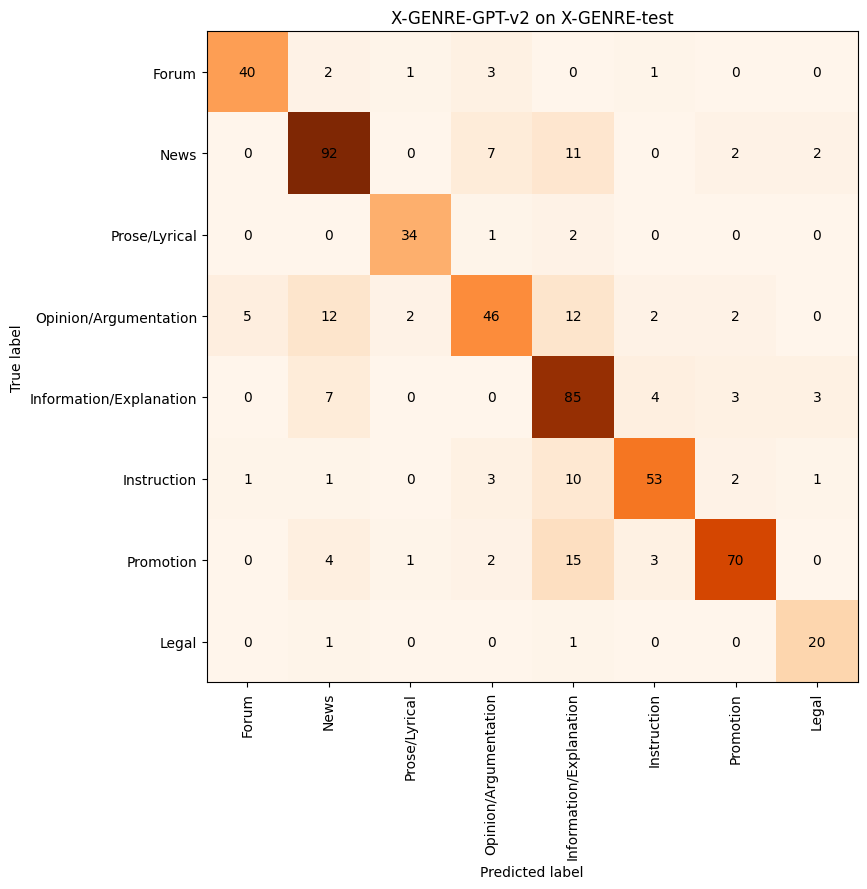

<Figure size 640x480 with 0 Axes>

In [22]:
# Calculate performance if we discard "Other"

test_df_filtered = test_df[test_df["labels"] != "Other"]

testing(test_df_filtered, f"pred_{model_path}", f"{model_path} on X-GENRE-test")

In [27]:
# Save the test set with predictions
test_df.to_json("X-GENRE-test.jsonl", orient="records", lines=True)

## EN-GINCO

In [29]:
# Open EN-GINCO file
enginco_df = pd.read_json("datasets/EN-GINCO.jsonl", orient="records", lines=True)

enginco_df.head()

,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Forum,Promotion,Forum
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News,News
2,Social Trip <p> On the evening of Wednesday 15...,Promotion,EN-GINCO,English,Promotion,Promotion,Promotion,Promotion
3,If the burner cap on your hob is not looking l...,Promotion,EN-GINCO,English,Instruction,Instruction,Instruction,Promotion
4,The following table summarises the relevance o...,Opinion/Argumentation,EN-GINCO,English,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation


In [30]:
# Truncate the texts to first 512 words - to be used for GPT-4o prediction
trunc_texts = []

for text in enginco_df["text"].to_list():
	current_trunc_text = " ".join(text.split(' ')[:512])
	trunc_texts.append(current_trunc_text)

enginco_df["trunc_text"] = trunc_texts
enginco_df.head(2)

,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE,trunc_text
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Forum,Promotion,Forum,Welcome to KBismarck.org! This is a community ...
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News,News,Why graft thrives in postconflict zones <p> A ...


In [31]:
en_ginco_dict = results_dict["enginco"]

en_ginco_dict

{'X-GENRE-GPT-v1': {'micro-F1': 0.6985294117647058,
  'macro-F1': 0.5962511231154254},
 'X-GENRE-GPT-v2': {'micro-F1': 0.7095588235294118,
  'macro-F1': 0.6097373829328476},
 'X-GENRE-GPT-v3': {'micro-F1': 0.6875, 'macro-F1': 0.5805292768371353},
 'X-GENRE': {'micro-F1': 0.6838235294117647, 'macro-F1': 0.6862472150541707}}

In [25]:
# Apply the original model
enginco_df = apply_x_genre(enginco_df)

enginco_df.head(3)

,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Forum,Promotion,Forum
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News,News
2,Social Trip <p> On the evening of Wednesday 15...,Promotion,EN-GINCO,English,Promotion,Promotion,Promotion,Promotion


In [27]:
model_path = "X-GENRE"

en_ginco_dict[model_path] = testing(enginco_df, f"pred_{model_path}", f"{model_path} on EN-GINCO")

en_ginco_dict

Macro f1: 0.686, Micro f1: 0.684
                         precision    recall  f1-score   support

                  Forum       0.69      0.55      0.61        20
Information/Explanation       0.76      0.55      0.64        64
            Instruction       0.28      1.00      0.43        10
                  Legal       1.00      1.00      1.00         1
                   News       0.72      0.89      0.80        46
  Opinion/Argumentation       0.72      0.62      0.67        50
                  Other       0.40      0.43      0.41        14
              Promotion       0.90      0.75      0.82        63
          Prose/Lyrical       0.67      1.00      0.80         4

               accuracy                           0.68       272
              macro avg       0.68      0.75      0.69       272
           weighted avg       0.74      0.68      0.69       272



{'X-GENRE-GPT-v1': {'micro-F1': 0.6985294117647058,
  'macro-F1': 0.5962511231154254},
 'X-GENRE-GPT-v2': {'micro-F1': 0.7095588235294118,
  'macro-F1': 0.6097373829328476},
 'X-GENRE-GPT-v3': {'micro-F1': 0.6875, 'macro-F1': 0.5805292768371353},
 'X-GENRE': {'micro-F1': 0.6838235294117647, 'macro-F1': 0.6862472150541707}}

In [49]:
model_path = "X-GENRE-GPT-v3"

en_ginco_dict[model_path] = testing(enginco_df, f"pred_{model_path}", f"{model_path} on EN-GINCO")

en_ginco_dict

Macro f1: 0.581, Micro f1: 0.688
                         precision    recall  f1-score   support

                  Forum       0.67      0.90      0.77        20
Information/Explanation       0.68      0.69      0.68        64
            Instruction       0.30      0.80      0.43        10
                  Legal       0.33      1.00      0.50         1
                   News       0.69      0.89      0.78        46
  Opinion/Argumentation       0.88      0.44      0.59        50
                  Other       0.00      0.00      0.00        14
              Promotion       0.84      0.78      0.81        63
          Prose/Lyrical       0.50      1.00      0.67         4

               accuracy                           0.69       272
              macro avg       0.54      0.72      0.58       272
           weighted avg       0.70      0.69      0.67       272



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

{'X-GENRE-GPT-v1': {'micro-F1': 0.6985294117647058,
  'macro-F1': 0.5962511231154254},
 'X-GENRE-GPT-v2': {'micro-F1': 0.7095588235294118,
  'macro-F1': 0.6097373829328476},
 'X-GENRE-GPT-v3': {'micro-F1': 0.6875, 'macro-F1': 0.5805292768371353}}

In [32]:
# Apply also the LLM directly

enginco_df = predict_genre("gpt-4o-2024-05-13", structured_prompt_label_description, enginco_df)

enginco_df.head()

100%|██████████| 272/272 [02:42<00:00,  1.67it/s]


,text,labels,dataset,language,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,pred_X-GENRE,trunc_text,pred_GPT
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Forum,Promotion,Forum,Welcome to KBismarck.org! This is a community ...,Promotion
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News,News,Why graft thrives in postconflict zones <p> A ...,News
2,Social Trip <p> On the evening of Wednesday 15...,Promotion,EN-GINCO,English,Promotion,Promotion,Promotion,Promotion,Social Trip <p> On the evening of Wednesday 15...,Promotion
3,If the burner cap on your hob is not looking l...,Promotion,EN-GINCO,English,Instruction,Instruction,Instruction,Promotion,If the burner cap on your hob is not looking l...,Instruction
4,The following table summarises the relevance o...,Opinion/Argumentation,EN-GINCO,English,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,The following table summarises the relevance o...,Information/Explanation


In [33]:
# Evaluate the model
model_path = "GPT"

en_ginco_dict[model_path] = testing(enginco_df, f"pred_{model_path}", f"{model_path} on EN-GINCO")

Macro f1: 0.587, Micro f1: 0.695
                         precision    recall  f1-score   support

                  Forum       0.74      0.85      0.79        20
Information/Explanation       0.71      0.64      0.67        64
            Instruction       0.37      0.70      0.48        10
                  Legal       0.25      1.00      0.40         1
                   News       0.68      0.85      0.76        46
  Opinion/Argumentation       0.83      0.58      0.68        50
                  Other       0.00      0.00      0.00        14
              Promotion       0.74      0.81      0.77        63
          Prose/Lyrical       0.57      1.00      0.73         4

               accuracy                           0.69       272
              macro avg       0.54      0.71      0.59       272
           weighted avg       0.68      0.69      0.68       272



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [34]:
print(pd.DataFrame(en_ginco_dict).transpose().sort_values(by="macro-F1", ascending=False).to_markdown())

|                |   micro-F1 |   macro-F1 |
|:---------------|-----------:|-----------:|
| X-GENRE        |   0.683824 |   0.686247 |
| X-GENRE-GPT-v2 |   0.709559 |   0.609737 |
| X-GENRE-GPT-v1 |   0.698529 |   0.596251 |
| GPT            |   0.694853 |   0.587247 |
| X-GENRE-GPT-v3 |   0.6875   |   0.580529 |


In [35]:
# Evaluate all models if we discard other

enginco_df_noother = enginco_df[enginco_df["labels"] != "Other"]
enginco_df_noother.labels.value_counts()

labels
Information/Explanation    64
Promotion                  63
Opinion/Argumentation      50
News                       46
Forum                      20
Instruction                10
Prose/Lyrical               4
Legal                       1
Name: count, dtype: int64

In [36]:
for model_path in ["GPT", "X-GENRE-GPT-v1", "X-GENRE-GPT-v2", "X-GENRE-GPT-v3", "X-GENRE"]:
	en_ginco_dict[f"{model_path}-wo-other"] = testing(enginco_df_noother, f"pred_{model_path}", f"{model_path} on EN-GINCO, without Other")

Macro f1: 0.705, Micro f1: 0.733
                         precision    recall  f1-score   support

                  Forum       0.77      0.85      0.81        20
Information/Explanation       0.71      0.64      0.67        64
            Instruction       0.37      0.70      0.48        10
                  Legal       0.33      1.00      0.50         1
                   News       0.72      0.85      0.78        46
  Opinion/Argumentation       0.91      0.58      0.71        50
              Promotion       0.78      0.81      0.80        63
          Prose/Lyrical       0.80      1.00      0.89         4

               accuracy                           0.73       258
              macro avg       0.67      0.80      0.70       258
           weighted avg       0.76      0.73      0.73       258

Macro f1: 0.727, Micro f1: 0.736
                         precision    recall  f1-score   support

                  Forum       0.81      0.85      0.83        20
Information/Explanat

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [37]:
print(pd.DataFrame(en_ginco_dict).transpose().sort_values(by="macro-F1", ascending=False).to_markdown())

|                         |   micro-F1 |   macro-F1 |
|:------------------------|-----------:|-----------:|
| X-GENRE-wo-other        |   0.710059 |   0.75192  |
| X-GENRE-GPT-v2-wo-other |   0.748062 |   0.747544 |
| X-GENRE-GPT-v1-wo-other |   0.736434 |   0.727297 |
| X-GENRE-GPT-v3-wo-other |   0.724806 |   0.704855 |
| GPT-wo-other            |   0.732558 |   0.704687 |
| X-GENRE                 |   0.683824 |   0.686247 |
| X-GENRE-GPT-v2          |   0.709559 |   0.609737 |
| X-GENRE-GPT-v1          |   0.698529 |   0.596251 |
| GPT                     |   0.694853 |   0.587247 |
| X-GENRE-GPT-v3          |   0.6875   |   0.580529 |


In [38]:
# Add to the results dict
results_dict["enginco"] = en_ginco_dict

results_dict

{'x-genre-test': {'X-GENRE-GPT-v3': {'micro-F1': 0.7466216216216216,
   'macro-F1': 0.6909763790831134},
  'X-GENRE-GPT-v1': {'micro-F1': 0.731418918918919,
   'macro-F1': 0.6811367813960743},
  'X-GENRE-GPT-v2': {'micro-F1': 0.7432432432432432,
   'macro-F1': 0.6916591344409126},
  'X-GENRE': {'micro-F1': 0.7972972972972973, 'macro-F1': 0.7935772031981144},
  'GPT': {'micro-F1': 0.7331081081081081, 'macro-F1': 0.6784895782090163},
  'GPT-wo-other': {'micro-F1': 0.7627416520210897,
   'macro-F1': 0.7789156945376791},
  'X-GENRE-GPT-v1-wo-other': {'micro-F1': 0.7609841827768014,
   'macro-F1': 0.7795750259447276},
  'X-GENRE-GPT-v2-wo-other': {'micro-F1': 0.773286467486819,
   'macro-F1': 0.7928999324362598},
  'X-GENRE-GPT-v3-wo-other': {'micro-F1': 0.7768014059753954,
   'macro-F1': 0.7906483523792458},
  'X-GENRE-wo-other': {'micro-F1': 0.8099027409372237,
   'macro-F1': 0.8221790096059651}},
 'enginco': {'X-GENRE-GPT-v1': {'micro-F1': 0.6985294117647058,
   'macro-F1': 0.59625112311

In [40]:
# Save the results dict
with open("genre-experiments-results.json", "w") as new_file:
	json.dump(results_dict, new_file, indent=2)

In [39]:
# Save the EN-GINCO with additional predictions
enginco_df.to_json("EN-GINCO.jsonl", orient="records", lines=True)

## Multilingual X-GENRE test set

In [55]:
# Open file
with open("multilingual-genre-annotated-test-set.json", "r") as test_file:
	multitest_dict = json.load(test_file)

multitest_dict.keys()

dict_keys(['mt', 'el', 'tr', 'sq', 'is', 'uk', 'ca', 'mk', 'hr', 'sl'])

In [ ]:
# Create a test set
text_ids = []
texts = []
translations = []
labels = []
preds = []
langs = []

for key in list(multitest_dict.keys()):
	current_df = pd.DataFrame(multitest_dict[key]["dataset"])
	text_ids.extend(current_df["text_id"].to_list())
	texts.extend(current_df["text"].to_list())
	translations.extend(current_df["translation"].to_list())
	labels.extend(current_df["y_true"].to_list())
	preds.extend(current_df["y_pred"].to_list())
	langs.extend([key]*len(current_df["y_true"].to_list()))

multitest_df = pd.DataFrame({"text": texts, "translation": translations, "labels": labels, "dataset": text_ids, "language": langs, "pred_X-GENRE": preds})

multitest_df.head(5)

In [65]:
multitest_df.describe()

,text,translation,labels,dataset,language,pred_X-GENRE
count,790,790,790,790,790,790
unique,790,790,8,790,10,8
top,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...","Angelo Chetcuti, will be replacing Bjorn Vassa...",Information/Explanation,macocu.mt.402244,el,News
freq,1,1,109,1,80,100


In [66]:
# Save the new test set
multitest_df.to_json("multilingual-X-GENRE-test-set.jsonl", orient="records", lines=True)

In [42]:
# Open the new test set
multitest_df = pd.read_json("datasets/multilingual-X-GENRE-test-set.jsonl", orient="records", lines=True)

multitest_df.head(3)

,text,translation,labels,dataset,language,pred_X-GENRE,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...","Angelo Chetcuti, will be replacing Bjorn Vassa...",News,macocu.mt.402244,mt,News,News,News,News
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,"Poltergeist refers to other woman's phenomena,...",Opinion/Argumentation,macocu.mt.377203,mt,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical
2,Chrysler: Brand ta 'lussu jew le? \n\nBrand ji...,Chrysler: Luxury brand or not?\n\nBrand moves ...,Opinion/Argumentation,macocu.mt.109995,mt,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation


In [43]:
# Truncate the texts to first 512 words - to be used for GPT-4o prediction
trunc_texts = []

for text in multitest_df["text"].to_list():
	current_trunc_text = " ".join(text.split(' ')[:512])
	trunc_texts.append(current_trunc_text)

multitest_df["trunc_text"] = trunc_texts
multitest_df.head(2)

,text,translation,labels,dataset,language,pred_X-GENRE,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,trunc_text
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...","Angelo Chetcuti, will be replacing Bjorn Vassa...",News,macocu.mt.402244,mt,News,News,News,News,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ..."
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,"Poltergeist refers to other woman's phenomena,...",Opinion/Argumentation,macocu.mt.377203,mt,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Poltergeist jirreferi għal fenomeni oħra tal-m...


Apply the classifiers to the test set

In [78]:
model_path = "X-GENRE-GPT-v3"
multitest_df = apply_model(multitest_df, model_path)

multitest_df.head(3)

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/simpletransformers/classification/classification_model.py:484: UserWarning: use_multiprocessing automatically disabled as xlmroberta fails when using multiprocessing for feature conversion.
  warnings.warn(


,text,translation,labels,dataset,language,pred_X-GENRE,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...","Angelo Chetcuti, will be replacing Bjorn Vassa...",News,macocu.mt.402244,mt,News,News,News,News
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,"Poltergeist refers to other woman's phenomena,...",Opinion/Argumentation,macocu.mt.377203,mt,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical
2,Chrysler: Brand ta 'lussu jew le? \n\nBrand ji...,Chrysler: Luxury brand or not?\n\nBrand moves ...,Opinion/Argumentation,macocu.mt.109995,mt,Forum,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation


In [33]:
multitest_df = apply_x_genre(multitest_df)

multitest_df.head(3)

,text,translation,labels,dataset,language,pred_X-GENRE,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...","Angelo Chetcuti, will be replacing Bjorn Vassa...",News,macocu.mt.402244,mt,News,News,News,News
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,"Poltergeist refers to other woman's phenomena,...",Opinion/Argumentation,macocu.mt.377203,mt,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical
2,Chrysler: Brand ta 'lussu jew le? \n\nBrand ji...,Chrysler: Luxury brand or not?\n\nBrand moves ...,Opinion/Argumentation,macocu.mt.109995,mt,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation


In [46]:
multiling_dict = results_dict["multilingual-X-GENRE-test"]
multiling_dict

{'X-GENRE-GPT-v1': {'micro-F1': 0.7632911392405063,
  'macro-F1': 0.7655957945514474},
 'X-GENRE-GPT-v2': {'micro-F1': 0.7569620253164557,
  'macro-F1': 0.7628347246090763},
 'X-GENRE-GPT-v3': {'micro-F1': 0.7518987341772152,
  'macro-F1': 0.7550345588279587},
 'X-GENRE': {'micro-F1': 0.8451776649746193, 'macro-F1': 0.8479136045690268}}

In [35]:
model_path = "X-GENRE"

multiling_dict[model_path] = testing(multitest_df, f"pred_{model_path}", f"{model_path} on Multiling-X-GENRE")

multiling_dict

Macro f1: 0.848, Micro f1: 0.845
                         precision    recall  f1-score   support

                  Forum       0.85      0.91      0.88        87
Information/Explanation       0.83      0.73      0.78       109
            Instruction       0.83      0.86      0.85        96
                  Legal       0.94      0.95      0.95        87
                   News       0.83      0.86      0.85       105
  Opinion/Argumentation       0.73      0.78      0.75       100
                  Other       0.00      0.00      0.00         0
              Promotion       0.89      0.79      0.84       107
          Prose/Lyrical       0.90      0.89      0.89        99

               accuracy                           0.84       790
              macro avg       0.76      0.75      0.75       790
           weighted avg       0.85      0.84      0.84       790



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

{'X-GENRE-GPT-v1': {'micro-F1': 0.7632911392405063,
  'macro-F1': 0.7655957945514474},
 'X-GENRE-GPT-v2': {'micro-F1': 0.7569620253164557,
  'macro-F1': 0.7628347246090763},
 'X-GENRE-GPT-v3': {'micro-F1': 0.7518987341772152,
  'macro-F1': 0.7550345588279587},
 'X-GENRE': {'micro-F1': 0.8451776649746193, 'macro-F1': 0.8479136045690268}}

In [44]:
# Apply also the LLM directly

multitest_df = predict_genre("gpt-4o-2024-05-13", structured_prompt_label_description, multitest_df)

multitest_df.head()

100%|██████████| 790/790 [07:58<00:00,  1.65it/s]


,text,translation,labels,dataset,language,pred_X-GENRE,pred_X-GENRE-GPT-v1,pred_X-GENRE-GPT-v2,pred_X-GENRE-GPT-v3,trunc_text,pred_GPT
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...","Angelo Chetcuti, will be replacing Bjorn Vassa...",News,macocu.mt.402244,mt,News,News,News,News,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...",News
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,"Poltergeist refers to other woman's phenomena,...",Opinion/Argumentation,macocu.mt.377203,mt,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Poltergeist jirreferi għal fenomeni oħra tal-m...,Opinion/Argumentation
2,Chrysler: Brand ta 'lussu jew le? \n\nBrand ji...,Chrysler: Luxury brand or not?\n\nBrand moves ...,Opinion/Argumentation,macocu.mt.109995,mt,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation,Chrysler: Brand ta 'lussu jew le? \n\nBrand ji...,Opinion/Argumentation
3,Kif tneħħi hangover sewwa u bla perikolu \n\nH...,How to remove a proper and safe hangover\n\nHa...,Instruction,macocu.mt.213859,mt,Forum,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Kif tneħħi hangover sewwa u bla perikolu \n\nH...,Instruction
4,Għalf Hills għall-qtates \n\nGħall-iżvilupp xi...,Feed hills for cats\n\nFor the proper developm...,Instruction,macocu.mt.70136,mt,Information/Explanation,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Għalf Hills għall-qtates \n\nGħall-iżvilupp xi...,Promotion


In [47]:
# Evaluate the model
model_path = "GPT"

multiling_dict[model_path] = testing(multitest_df, f"pred_{model_path}", f"{model_path} on X-GINCO")

Macro f1: 0.799, Micro f1: 0.795
                         precision    recall  f1-score   support

                  Forum       0.91      0.91      0.91        87
Information/Explanation       0.66      0.69      0.68       109
            Instruction       0.85      0.75      0.80        96
                  Legal       0.88      0.94      0.91        87
                   News       0.69      0.93      0.79       105
  Opinion/Argumentation       0.77      0.59      0.67       100
              Promotion       0.76      0.74      0.75       107
          Prose/Lyrical       0.95      0.85      0.90        99

               accuracy                           0.79       790
              macro avg       0.81      0.80      0.80       790
           weighted avg       0.80      0.79      0.79       790



In [48]:
print(pd.DataFrame(multiling_dict).transpose().sort_values(by="macro-F1", ascending=False).to_markdown())

|                |   micro-F1 |   macro-F1 |
|:---------------|-----------:|-----------:|
| X-GENRE        |   0.845178 |   0.847914 |
| GPT            |   0.794937 |   0.799327 |
| X-GENRE-GPT-v1 |   0.763291 |   0.765596 |
| X-GENRE-GPT-v2 |   0.756962 |   0.762835 |
| X-GENRE-GPT-v3 |   0.751899 |   0.755035 |


In [36]:
# Add to the results dict
results_dict["multilingual-X-GENRE-test"] = multiling_dict

results_dict

{'x-genre-test': {'X-GENRE-GPT-v3': {'micro-F1': 0.7466216216216216,
   'macro-F1': 0.6909763790831134},
  'X-GENRE-GPT-v1': {'micro-F1': 0.731418918918919,
   'macro-F1': 0.6811367813960743},
  'X-GENRE-GPT-v2': {'micro-F1': 0.7432432432432432,
   'macro-F1': 0.6916591344409126},
  'X-GENRE': {'micro-F1': 0.7972972972972973, 'macro-F1': 0.7935772031981144}},
 'enginco': {'X-GENRE-GPT-v1': {'micro-F1': 0.6985294117647058,
   'macro-F1': 0.5962511231154254},
  'X-GENRE-GPT-v2': {'micro-F1': 0.7095588235294118,
   'macro-F1': 0.6097373829328476},
  'X-GENRE-GPT-v3': {'micro-F1': 0.6875, 'macro-F1': 0.5805292768371353},
  'X-GENRE': {'micro-F1': 0.6838235294117647, 'macro-F1': 0.6862472150541707}},
 'multilingual-X-GENRE-test': {'X-GENRE-GPT-v1': {'micro-F1': 0.7632911392405063,
   'macro-F1': 0.7655957945514474},
  'X-GENRE-GPT-v2': {'micro-F1': 0.7569620253164557,
   'macro-F1': 0.7628347246090763},
  'X-GENRE-GPT-v3': {'micro-F1': 0.7518987341772152,
   'macro-F1': 0.7550345588279587},

In [37]:
# Save the dataset
multitest_df.to_json("multilingual-X-GENRE-test-set.jsonl", orient="records", lines=True)

In [38]:
# Save the results dict
with open("genre-experiments-results.json", "w") as new_file:
	json.dump(results_dict, new_file, indent=2)